# Figure6_3

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure6")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from functions.load_data import loadTrialsM
from functions.utils import index_in
from functions.sensitivity import load_human_fits, load_monkey_fits
from functions.plotting import set_paper_theme

set_paper_theme(tick_width=0.3)


### Sensitivity for control task

In [3]:
tasks = [
    "animate_vs_inanimate_cartoon",
    "animate_vs_inanimate_silhouette",
    "animate_vs_inanimate_outline"]
subj_list = [
    ["014","041","044","073"],
    ["014","041","044","073"],
    ["014","041","044","073"],
]

subfixes= [
    "cartoon","silhouette","outline"]

In [4]:
kmonkey,khuman = [],[]
for i,(task,subfix) in enumerate(zip(tasks,subfixes)):
    uimg_monkey,k_monkey = load_monkey_fits(task)
    uimg_human,k_human = load_human_fits(task,subj_list[i])
    
    trials,files = loadTrialsM(task,"Elsa")
    images_control = list(set([tr["img_url"].split("/")[-1] for tr in trials if tr["img_url"].split("/")[-3].endswith(subfix)]))
    idx = index_in(images_control,uimg_human[0])
    kavg_monkey = np.mean([k[idx] for k in k_monkey],axis=0)
    kavg_human = np.mean([k[idx] for k in k_human],axis=0)
    kmonkey.append(kavg_monkey)
    khuman.append(kavg_human)

In [5]:
correlation = [np.corrcoef(kmonkey[i],khuman[i])[0,1] for i in range(len(tasks))]
correlation_se = [np.sqrt((1-correlation[i]**2)/(len(khuman[i])-2)) for i in range(len(tasks))]

# Shared palette for panels G and H.
colors = sns.color_palette("Dark2")


## Panel G - Control sensitivity scatter plot

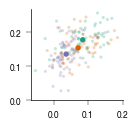

In [6]:
fig,ax = plt.subplots()
fig.set(figwidth=95/75,figheight=95/75)
ax.set_box_aspect(1)
for i in range(3): ax.scatter(kmonkey[i],khuman[i],color=(colors[i],0.25),edgecolors='None',s=5)
for i in range(3): ax.scatter(np.mean(kmonkey[i]),np.mean(khuman[i]),marker='o',color=colors[i],edgecolors='None',s=15)
ax.set_xticks([0,0.1,0.2])
ax.set_yticks([0,0.1,0.2])
plt.savefig(FIGURE_OUTPUT_DIR / f"control_sensitivity_scatter.pdf")
plt.show()

## Panel H - Control correlation summary

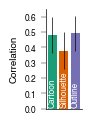

In [7]:
fig,ax = plt.subplots()
fig.set(figheight=85/75,figwidth=60/75)
ax.bar(range(len(tasks)),correlation,color=colors[:3],yerr=correlation_se,error_kw={"linewidth":0.5})
for i in range(len(tasks)): ax.text(i,0.02,["Cartoon","Silhouette","Outline"][i],color="white",horizontalalignment="center",fontsize=6,rotation=90)
ax.set_xticks([])
ax.set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6])
ax.set_ylabel("Correlation")
ax.set_ylim([0,0.65])
plt.savefig(FIGURE_OUTPUT_DIR / f"control_sensitivity_correlation.pdf")
plt.show()